# 📊 Bài Tập Về Nhà — Buổi 2
## Xác Suất Thống Kê cho AI
**Hạn nộp:** 30/6/2026

---

## -> Import thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Tất cả thư viện đã được import thành công!")


Tất cả thư viện đã được import thành công!


---
## -> Phần 1 — Thống Kê Mô Tả & Đặc Trưng

### 1.1 Đọc dữ liệu, hiển thị 5 dòng đầu, số dòng/cột, kiểu dữ liệu

In [2]:
df = sns.load_dataset("iris")

print("=== 5 dòng đầu tiên ===")
print(df.head())

print(f"\n=== Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột ===")

print("\n=== Kiểu dữ liệu từng cột ===")
print(df.dtypes)


=== 5 dòng đầu tiên ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Kích thước: 150 dòng x 5 cột ===

=== Kiểu dữ liệu từng cột ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### 1.2 Tính các chỉ số thống kê cho từng biến số

In [3]:
so_cols = df.select_dtypes(include="number").columns

for col in so_cols:
    mean   = df[col].mean()
    median = df[col].median()
    mode   = df[col].mode()[0]
    var    = df[col].var()
    std    = df[col].std()
    min_v  = df[col].min()
    max_v  = df[col].max()
    q1     = df[col].quantile(0.25)
    q3     = df[col].quantile(0.75)
    iqr    = q3 - q1

    print(f"--- {col} ---")
    print(f"  Mean   : {mean:.4f}")
    print(f"  Median : {median:.4f}")
    print(f"  Mode   : {mode:.4f}")
    print(f"  Var    : {var:.4f}")
    print(f"  Std    : {std:.4f}")
    print(f"  Min    : {min_v:.4f}")
    print(f"  Max    : {max_v:.4f}")
    print(f"  Q1     : {q1:.4f}")
    print(f"  Q3     : {q3:.4f}")
    print(f"  IQR    : {iqr:.4f}")
    print()


--- sepal_length ---
  Mean   : 5.8433
  Median : 5.8000
  Mode   : 5.0000
  Var    : 0.6857
  Std    : 0.8281
  Min    : 4.3000
  Max    : 7.9000
  Q1     : 5.1000
  Q3     : 6.4000
  IQR    : 1.3000

--- sepal_width ---
  Mean   : 3.0573
  Median : 3.0000
  Mode   : 3.0000
  Var    : 0.1900
  Std    : 0.4359
  Min    : 2.0000
  Max    : 4.4000
  Q1     : 2.8000
  Q3     : 3.3000
  IQR    : 0.5000

--- petal_length ---
  Mean   : 3.7580
  Median : 4.3500
  Mode   : 1.4000
  Var    : 3.1163
  Std    : 1.7653
  Min    : 1.0000
  Max    : 6.9000
  Q1     : 1.6000
  Q3     : 5.1000
  IQR    : 3.5000

--- petal_width ---
  Mean   : 1.1993
  Median : 1.3000
  Mode   : 0.2000
  Var    : 0.5810
  Std    : 0.7622
  Min    : 0.1000
  Max    : 2.5000
  Q1     : 0.3000
  Q3     : 1.8000
  IQR    : 1.5000



### 1.3 Tính mean & std theo từng loài (groupby species)

#### Sau khi .groupby("species") — tách thành 3 nhóm

- Nhóm setosa     → 50 dòng (dòng 0   → 49)
- Nhóm versicolor → 50 dòng (dòng 50  → 99)
- Nhóm virginica  → 50 dòng (dòng 100 → 149)

In [4]:
ket_qua = df.groupby("species")[so_cols].agg(["mean", "std"])
print(ket_qua.round(3)) #lấy 3 chữ số thập phân cho chill


           sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.428  0.379        1.462  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.246  0.105  
versicolor       1.326  0.198  
virginica        2.026  0.275  


> **Nhận xét:** Loài **virginica** có giá trị trung bình lớn nhất ở hầu hết các biến 
> (đặc biệt `petal_length` và `petal_width`). Loài **setosa** khác biệt rõ nhất so với 
> 2 loài còn lại — kích thước cánh hoa rất nhỏ.

---
## -> Phần 2 — Phân Phối Xác Suất

### 2.1 Histogram + KDE cho từng biến số

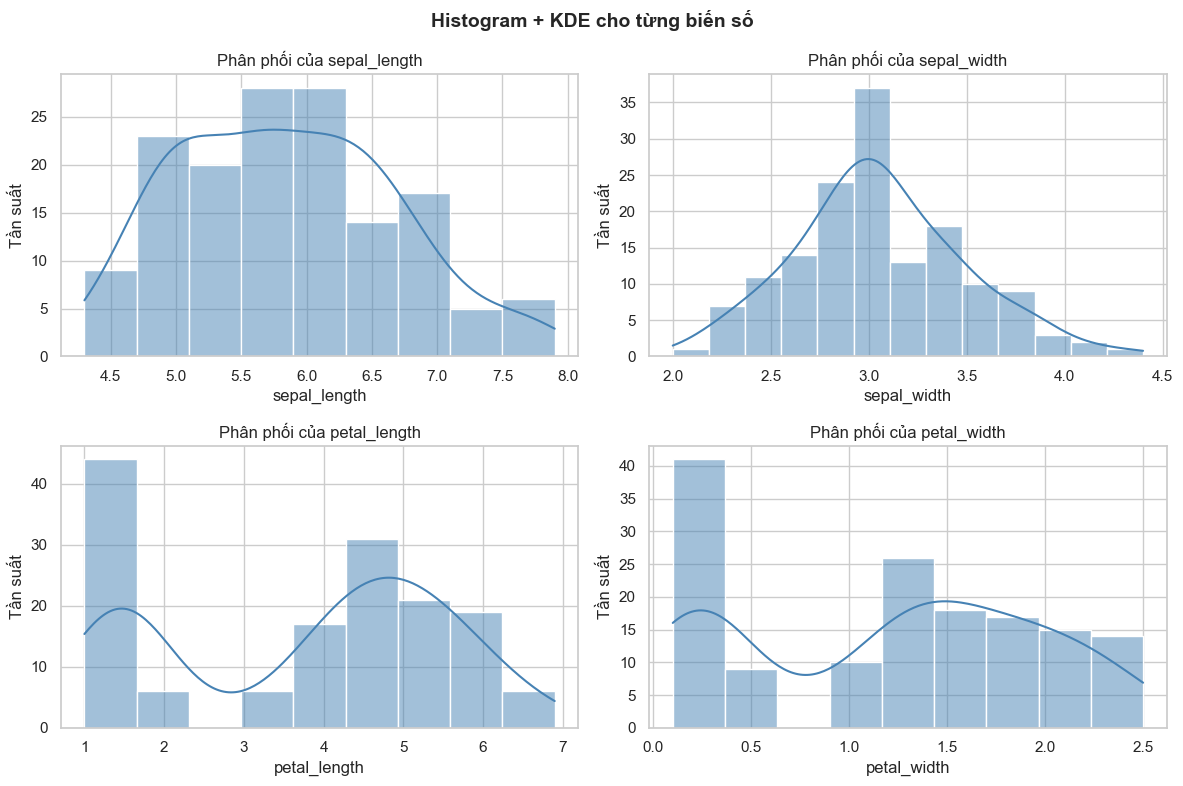

Đã lưu ảnh: phan2_histogram_kde.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(so_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")

plt.suptitle("Histogram + KDE cho từng biến số", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("phan2_histogram_kde.png", dpi=150)
plt.show()
print("Đã lưu ảnh: phan2_histogram_kde.png")


> **Nhận xét:**  
> - `sepal_length` và `sepal_width`: gần phân phối chuẩn, ít lệch.  
> - `petal_length` và `petal_width`: có **2 đỉnh** (bimodal) — do dữ liệu đến từ 3 loài khác nhau.

### 2.2 Boxplot từng biến theo nhóm loài (species)

#### 5 thành phần box plot:
         ├───────────┤
Min  Q1  │   Median  │  Q3       Max
 ●───────│─────│─────│───────────●
         ├───────────┤
              Box
         └─── IQR ───┘

C:\Users\84932\AppData\Local\Temp\ipykernel_10552\2800126237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\84932\AppData\Local\Temp\ipykernel_10552\2800126237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\84932\AppData\Local\Temp\ipykernel_10552\2800126237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="species", y=col, data=df, ax=axes[i], palette="Set2")
C:\Users\84932\AppData\Local\Temp\ipy

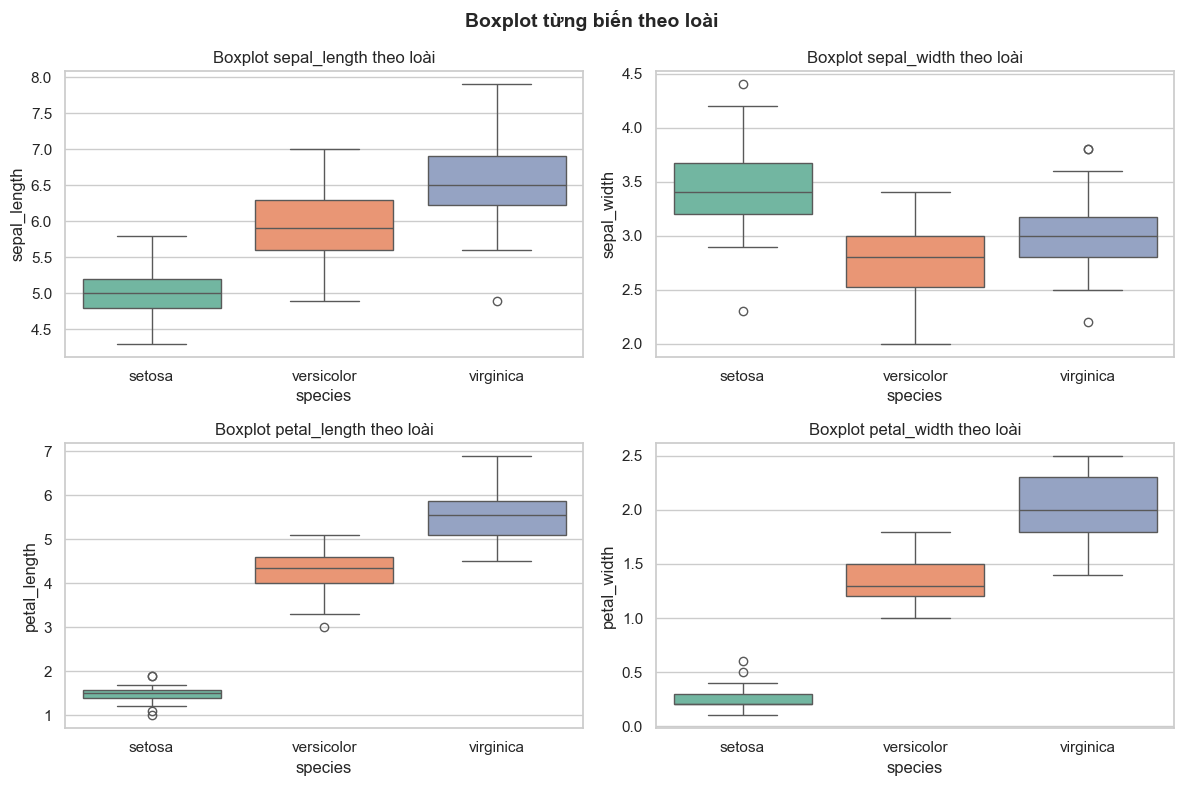

Đã lưu ảnh: phan2_boxplot.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(so_cols):
    sns.boxplot(x="species", y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Boxplot {col} theo loài")

plt.suptitle("Boxplot từng biến theo loài", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("phan2_boxplot.png", dpi=150)
plt.show()
print("Đã lưu ảnh: phan2_boxplot.png")


### 2.3 Mô phỏng: so sánh dữ liệu thực với phân phối Normal lý thuyết

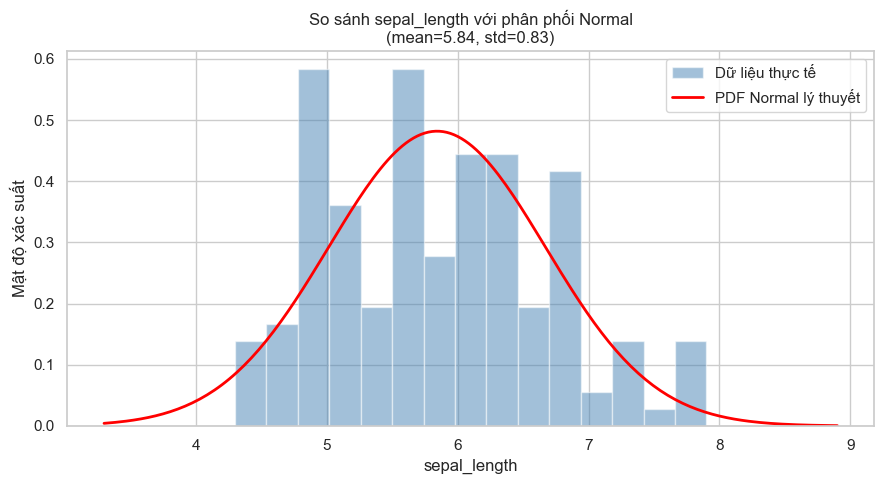

In [7]:
col_chon = "sepal_length"

mean_thuc = df[col_chon].mean()
std_thuc  = df[col_chon].std()

mau_normal = np.random.normal(loc=mean_thuc, scale=std_thuc, size=1000)

x = np.linspace(df[col_chon].min() - 1, df[col_chon].max() + 1, 200)

pdf_ly_thuyet = (1 / (std_thuc * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_thuc) / std_thuc) ** 2)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df[col_chon], bins=15, density=True, alpha=0.5,
        color="steelblue", label="Dữ liệu thực tế")
ax.plot(x, pdf_ly_thuyet, color="red", linewidth=2, label="PDF Normal lý thuyết")

ax.set_title(f"So sánh {col_chon} với phân phối Normal\n"
             f"(mean={mean_thuc:.2f}, std={std_thuc:.2f})")
ax.set_xlabel(col_chon)
ax.set_ylabel("Mật độ xác suất")
ax.legend()
plt.tight_layout()
plt.show()

> **Nhận xét:** `sepal_length` khớp một phần với phân phối Normal — vùng giữa (5.5 → 7.0) tương đối gần đường PDF. Tuy nhiên có 2 đỉnh (bimodal) ở ~5.0 và ~6.0 thay vì 1 đỉnh duy nhất — nguyên nhân là dữ liệu gộp từ 3 loài có kích thước khác nhau, nên tổng thể không phải phân phối chuẩn thuần túy.

---
## -> Phần 3 — Phân Tích Đa Biến & Tương Quan

### 3.1 Ma trận hiệp phương sai & ma trận tương quan

In [8]:
print("=== Ma trận Hiệp Phương Sai (Covariance) ===")
print(df[so_cols].cov().round(4))

print("\n=== Ma trận Tương Quan (Correlation) ===")
print(df[so_cols].corr().round(4))


=== Ma trận Hiệp Phương Sai (Covariance) ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        0.6857      -0.0424        1.2743       0.5163
sepal_width        -0.0424       0.1900       -0.3297      -0.1216
petal_length        1.2743      -0.3297        3.1163       1.2956
petal_width         0.5163      -0.1216        1.2956       0.5810

=== Ma trận Tương Quan (Correlation) ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        1.0000      -0.1176        0.8718       0.8179
sepal_width        -0.1176       1.0000       -0.4284      -0.3661
petal_length        0.8718      -0.4284        1.0000       0.9629
petal_width         0.8179      -0.3661        0.9629       1.0000


### 3.2 Heatmap tương quan

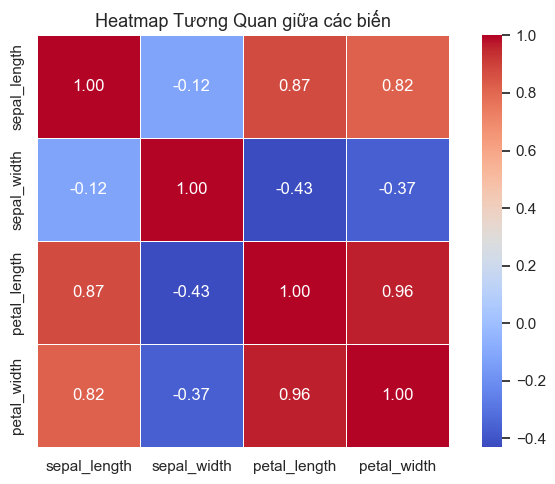

Đã lưu ảnh: phan3_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ma_tran_corr = df[so_cols].corr()
sns.heatmap(ma_tran_corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Heatmap Tương Quan giữa các biến", fontsize=13)

plt.tight_layout()
#plt.savefig("phan3_heatmap.png", dpi=150)
plt.show()
print("Đã lưu ảnh: phan3_heatmap.png")


> **Nhận xét:**  
> - Cặp tương quan **mạnh nhất**: `petal_length` và `petal_width` (~0.96) — tương quan dương rất cao.  
> - `petal_length` & `sepal_length` cũng tương quan cao (~0.87).  
> - Có **dấu hiệu đa cộng tuyến** giữa `petal_length` và `petal_width` vì r > 0.9.

### 3.3 Pairplot tô màu theo loài

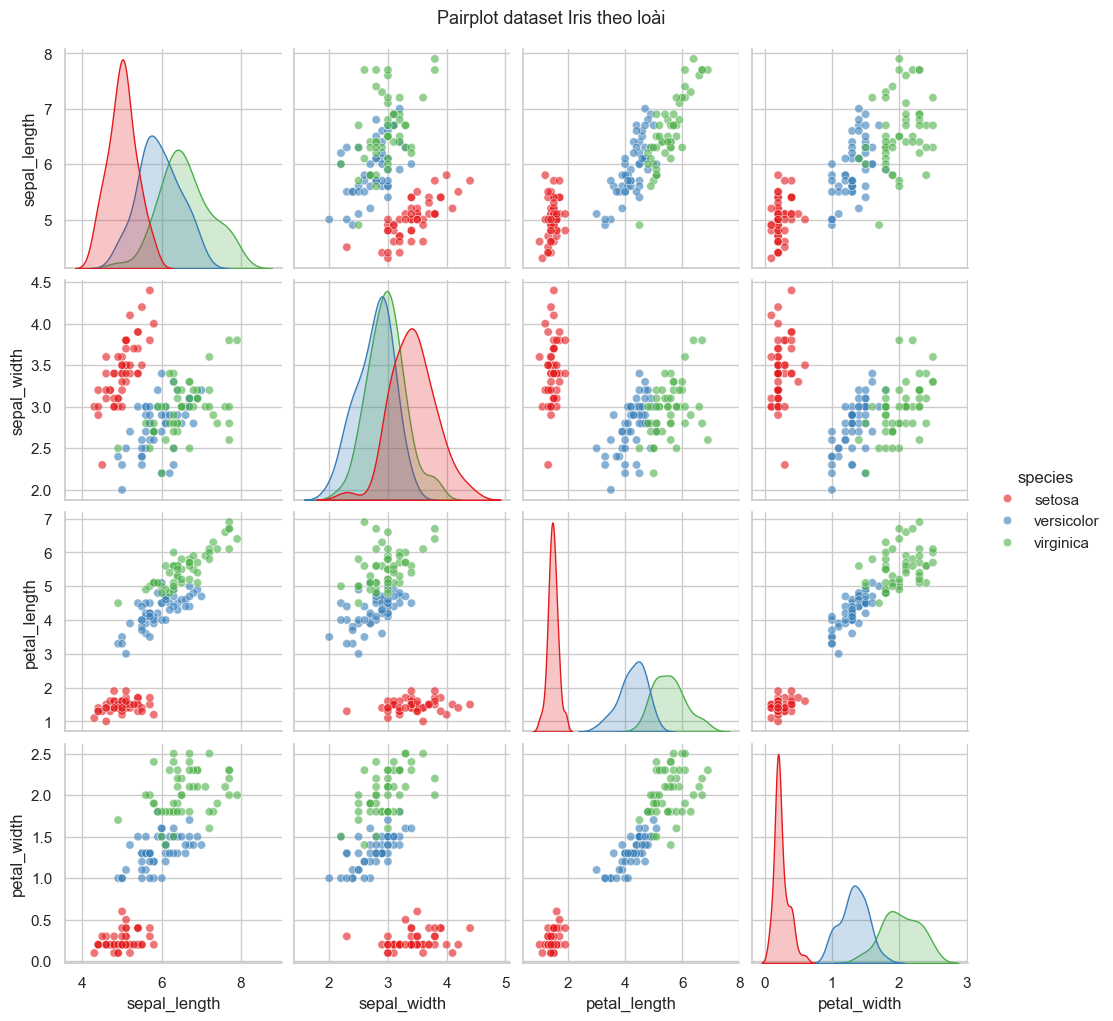

Đã lưu ảnh: phan3_pairplot.png


In [10]:
pairplot_fig = sns.pairplot(df, hue="species", palette="Set1", 
                             plot_kws={"alpha": 0.6})
pairplot_fig.figure.suptitle("Pairplot dataset Iris theo loài", 
                              y=1.02, fontsize=13)
#pairplot_fig.savefig("phan3_pairplot.png", dpi=120)
plt.show()
print("Đã lưu ảnh: phan3_pairplot.png")


> **Nhận xét:**  
> - Loài **setosa** (đỏ) tách biệt hoàn toàn với 2 loài còn lại ở `petal_length` và `petal_width`.  
> - **versicolor** và **virginica** có vùng chồng lấp nhau ở một số biến.  
> - `petal_length` và `petal_width` là cặp biến phân biệt loài tốt nhất.

---
##  Phần 4 — Xác Suất & Định Lý Bayes

### 4.1 Tính xác suất hậu nghiệm P(B|+) bằng định lý Bayes

In [11]:
P_B            = 0.01   # tỉ lệ mắc bệnh trong dân số
P_pos_givenB   = 0.99   # độ nhạy (true positive)
P_pos_givenNB  = 0.05   # dương tính giả (false positive)

P_pos       = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print(f"P(+)     = {P_pos:.4f}  (xác suất xét nghiệm dương tính)")
print(f"P(B|+)   = {P_B_given_pos:.4f}  (xác suất thực sự mắc bệnh khi xét nghiệm dương)")
print(f"=> Chỉ có {P_B_given_pos*100:.1f}% người có kết quả dương tính là thực sự mắc bệnh!")


P(+)     = 0.0594  (xác suất xét nghiệm dương tính)
P(B|+)   = 0.1667  (xác suất thực sự mắc bệnh khi xét nghiệm dương)
=> Chỉ có 16.7% người có kết quả dương tính là thực sự mắc bệnh!


> **Giải thích:** Dù xét nghiệm rất nhạy (99%), nhưng vì bệnh **rất hiếm** (chỉ 1%), 
> số người âm tính giả trong quần thể lớn vẫn vượt trội số người thực sự mắc bệnh. 
> Đây là hiện tượng **"base rate fallacy"** — kết quả dương tính không có nghĩa là chắc chắn mắc bệnh.

### 4.2 Khảo sát P(B|+) khi tỉ lệ mắc bệnh thay đổi từ 0.001 đến 0.2

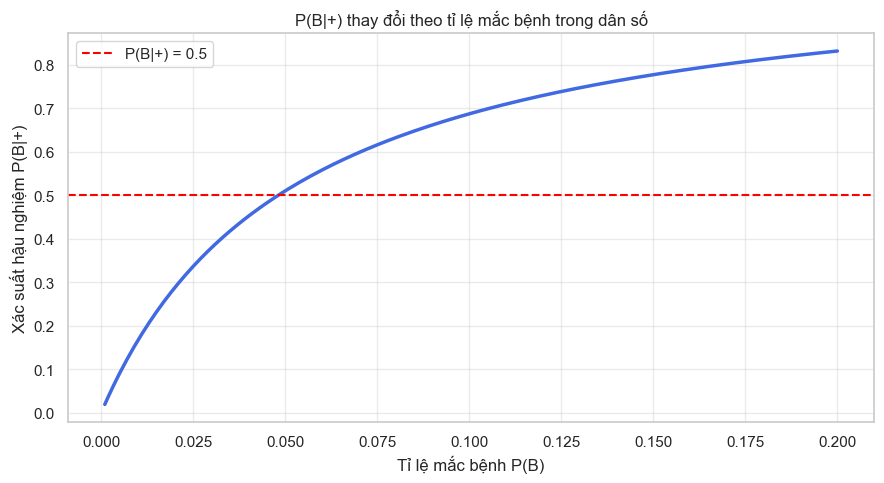

Đã lưu ảnh: phan4_bayes_curve.png


In [12]:
ti_le_mac = np.linspace(0.001, 0.2, 200)

p_pos_vec       = P_pos_givenB * ti_le_mac + P_pos_givenNB * (1 - ti_le_mac)
p_b_given_pos_vec = P_pos_givenB * ti_le_mac / p_pos_vec

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ti_le_mac, p_b_given_pos_vec, color="royalblue", linewidth=2.5)
ax.axhline(y=0.5, color="red", linestyle="--", label="P(B|+) = 0.5")
ax.set_xlabel("Tỉ lệ mắc bệnh P(B)")
ax.set_ylabel("Xác suất hậu nghiệm P(B|+)")
ax.set_title("P(B|+) thay đổi theo tỉ lệ mắc bệnh trong dân số")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
#plt.savefig("phan4_bayes_curve.png", dpi=150)
plt.show()
print("Đã lưu ảnh: phan4_bayes_curve.png")


> **Giải thích — tại sao "phản trực giác"?**  
> Khi bệnh **rất hiếm** (P(B) nhỏ), dù xét nghiệm chính xác cao, vẫn có **rất nhiều người 
> khỏe mạnh bị dương tính giả** (false positive). Số người dương tính giả nhiều hơn 
> số người thật sự bệnh → P(B|+) rất thấp.  
> Chỉ khi tỉ lệ mắc bệnh đủ lớn thì P(B|+) mới vượt 0.5 — tức là mới "đáng tin".

# Bonus — Bộ lọc Spam đơn giản với Naive Bayes

In [13]:
emails_huan_luyen = [
    "get free money now win prize",
    "click here to claim your reward free",
    "you won a lottery prize claim now",
    "free offer limited time click win",
    "meeting at 3pm tomorrow project update",
    "please review the attached report",
    "team lunch friday schedule confirmed",
    "project deadline is next monday reminder",
]
nhan_han = [1, 1, 1, 1, 0, 0, 0, 0]

# ── BƯỚC 1: tách từ và đếm ──────────────────────────────────────────────────
tu_dien = {}
for email, nhan in zip(emails_huan_luyen, nhan_han):
    for tu in email.split():
        if tu not in tu_dien:
            tu_dien[tu] = {"spam": 0, "khong_spam": 0}
        if nhan == 1:
            tu_dien[tu]["spam"] += 1
        else:
            tu_dien[tu]["khong_spam"] += 1

df_tu = pd.DataFrame(tu_dien).T.fillna(0)
df_tu.index.name = "tu"

# ── BƯỚC 2: tính xác suất tiên nghiệm P(spam) và P(không spam) ──────────────
tong = len(nhan_han)
p_spam     = sum(nhan_han) / tong
p_khong_spam = 1 - p_spam

# ── BƯỚC 3: tính P(từ | spam) và P(từ | không spam) với Laplace smoothing ───
tong_tu_spam      = df_tu["spam"].sum()
tong_tu_khong_spam = df_tu["khong_spam"].sum()
so_tu_duy_nhat    = len(df_tu)

df_tu["p_tu_spam"]      = (df_tu["spam"] + 1) / (tong_tu_spam + so_tu_duy_nhat)
df_tu["p_tu_khong_spam"] = (df_tu["khong_spam"] + 1) / (tong_tu_khong_spam + so_tu_duy_nhat)

# ── BƯỚC 4: hàm dự đoán ─────────────────────────────────────────────────────
def du_doan_bayes(email):
    cac_tu = email.split()

    log_spam      = np.log(p_spam)
    log_khong_spam = np.log(p_khong_spam)

    for tu in cac_tu:
        if tu in df_tu.index:
            log_spam      += np.log(df_tu.loc[tu, "p_tu_spam"])
            log_khong_spam += np.log(df_tu.loc[tu, "p_tu_khong_spam"])
        else:
            # từ chưa gặp → Laplace smoothing
            log_spam      += np.log(1 / (tong_tu_spam + so_tu_duy_nhat))
            log_khong_spam += np.log(1 / (tong_tu_khong_spam + so_tu_duy_nhat))

    # chuyển từ log về xác suất
    max_log   = max(log_spam, log_khong_spam)
    exp_spam  = np.exp(log_spam - max_log)
    exp_khong = np.exp(log_khong_spam - max_log)
    tong_exp  = exp_spam + exp_khong

    p_spam_posterior = exp_spam / tong_exp
    return p_spam_posterior

# ── BƯỚC 5: test ─────────────────────────────────────────────────────────────
email_test = [
    "free money prize click here",
    "project meeting schedule tomorrow",
    "win free reward claim now",
]

print("=" * 60)
for email in email_test:
    p = du_doan_bayes(email)
    nhan = "SPAM " if p >= 0.5 else "KHÔNG SPAM "
    print(f"Email: '{email}'")
    print(f"  => Phân loại: {nhan}  |  P(spam|email) = {p:.4f}")
    print()

Email: 'free money prize click here'
  => Phân loại: SPAM   |  P(spam|email) = 0.9906

Email: 'project meeting schedule tomorrow'
  => Phân loại: KHÔNG SPAM   |  P(spam|email) = 0.0314

Email: 'win free reward claim now'
  => Phân loại: SPAM   |  P(spam|email) = 0.9937



> **Nhận xét:** Mô hình Naive Bayes học các từ hay xuất hiện trong email spam 
> (như "free", "money", "prize", "win") và tính xác suất P(spam|email) 
> dựa trên định lý Bayes với giả định các từ **độc lập** nhau (naive assumption).
> 
> ---
